# Hands-On Lab: Cross-Validating a Titanic Survival Model
<hr style="height: 5px; background-color: #b33c3c ; border: none;">


## 1. Import the Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score,classification_report, roc_curve,confusion_matrix

## 2. Load the Titanic Dataset

In [2]:
df=pd.read_csv("titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,\N,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,\N,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,\N,S



The dataset contains **891 passengers and 12 columns**. The next question is: **What information do we have before building the model?**

The first rows show variables such as Name, Sex, Age, Parch, Ticket, and Survived.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 3. Check the Dataset Size

In [3]:
df.shape

(891, 12)


The shape is **(891, 12)**, so the dataset contains 891 traveler records and 12 columns.

This gives us enough observations to create separate training, validation, and test sets.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 4. Check for Missing Values

In [4]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

### Interpretation
The missing values show why data preparation is necessary before asking the model to learn patterns from the traveler records.


## 5. Handle Missing Values

In [5]:
df.fillna(df.mode().iloc[0],inplace=True)
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

### Interpretation
The dataset is now complete, so missing entries will not directly prevent the model from being trained or evaluated.



Missing values are filled using the mode of each column. After this step, all columns report **0 missing values**.

This allows the later modelling steps to work with a complete dataset.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 7. Prepare the Features

In [6]:
x=df.drop(['Survived','PassengerId'],axis=1)
y=df['Survived']

category_cols=x.select_dtypes(include=['object']).columns

x=pd.get_dummies(x,columns=category_cols,drop_first=True)
print("X shape after encoding: ",x.shape)
print("Columns: ",x.columns.tolist())

X shape after encoding:  (891, 1813)
Columns:  ['Pclass', 'SibSp', 'Parch', 'Fare', 'Name_Abbott, Mr. Rossmore Edward', 'Name_Abbott, Mrs. Stanton (Rosa Hunt)', 'Name_Abelson, Mr. Samuel', 'Name_Abelson, Mrs. Samuel (Hannah Wizosky)', 'Name_Adahl, Mr. Mauritz Nils Martin', 'Name_Adams, Mr. John', 'Name_Ahlin, Mrs. Johan (Johanna Persdotter Larsson)', 'Name_Aks, Mrs. Sam (Leah Rosen)', 'Name_Albimona, Mr. Nassef Cassem', 'Name_Alexander, Mr. William', 'Name_Alhomaki, Mr. Ilmari Rudolf', 'Name_Ali, Mr. Ahmed', 'Name_Ali, Mr. William', 'Name_Allen, Miss. Elisabeth Walton', 'Name_Allen, Mr. William Henry', 'Name_Allison, Master. Hudson Trevor', 'Name_Allison, Miss. Helen Loraine', 'Name_Allison, Mrs. Hudson J C (Bessie Waldo Daniels)', 'Name_Allum, Mr. Owen George', 'Name_Andersen-Jensen, Miss. Carla Christine Nielsine', 'Name_Anderson, Mr. Harry', 'Name_Andersson, Master. Sigvard Harald Elias', 'Name_Andersson, Miss. Ebba Iris Alfrida', 'Name_Andersson, Miss. Ellis Anna Maria', 'Name_Ande

C:\Users\pc\AppData\Local\Temp\ipykernel_2424\3521578602.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_cols=x.select_dtypes(include=['object']).columns


### Interpretation
The resulting feature matrix contains numerical variables that can be passed to the Logistic Regression model. The identifier is excluded because it does not represent a meaningful traveler characteristic.




The target `Survived` and identifier `PassengerId` are removed from the features. Categorical variables are then converted into numerical dummy variables.

After encoding, the model has **12 input features**. This step changes categorical information into a numerical form that Logistic Regression can use.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 8. Create Training, Validation, and Test Sets

In [7]:
x_temp,x_test,y_temp,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_val,y_train,y_val=train_test_split(x_temp,y_temp,test_size=0.25,random_state=42)

print("Training set shape: ",x_train.shape)
print("Validation set shape: ",x_val.shape)
print("Test set shape: ",x_test.shape)

Training set shape:  (534, 1813)
Validation set shape:  (178, 1813)
Test set shape:  (179, 1813)


### Why this matters
Training, validation, and testing have different jobs. Keeping the test set untouched prevents us from using the final answer while choosing the model.



### Question
**Why do we need three different datasets?**

- **Training set:** used to learn the model.
- **Validation set:** used during development to choose the best hyperparameter.
- **Test set:** kept unseen until the final evaluation.

The split is **600 training, 200 validation, and 200 test observations**.

The test set is therefore kept separate from model selection, which gives us a fair final estimate.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 9. Establishing a Baseline Model

Before deliberately creating underfitting and overfitting, I will establish a baseline Decision Tree.

I will use a moderate maximum depth of 5.

The question is:

> How does a reasonably constrained Decision Tree perform before deliberately changing its complexity?

In [8]:
model = DecisionTreeClassifier(max_depth=5,random_state=42)

model.fit(x_train, y_train)

model_train_score = model.score(x_train,y_train)
model_val_score = model.score(x_val,y_val)
model_gap = ( model_train_score - model_val_score)

print("Training Score:", model_train_score)
print("Validation Score:", model_val_score)
print("Train-Validation Gap:", model_gap)

Training Score: 0.850187265917603
Validation Score: 0.8146067415730337
Train-Validation Gap: 0.035580524344569264


### Interpretation
The baseline provides a reference point for the experiments that follow.

The most important values are:

- Training score
- Validation score
- Train-validation gap

I will now intentionally increase the model complexity to investigate overfitting.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 10. Step 1 — Deliberately Creating an Overfitted Model

To demonstrate overfitting, I will create a very deep Decision Tree.

I will remove the maximum depth restriction by setting `max_depth=None`.

This gives the model enough flexibility to create very detailed rules for the training data.

The question is:

> Will the model perform much better on the training data than on unseen validation data?

In [9]:
overfit_model = DecisionTreeClassifier(max_depth=None,random_state=42)

overfit_model.fit(x_train, y_train)

overfit_train_score = overfit_model.score(x_train,y_train)
overfit_val_score = overfit_model.score(x_val,y_val)
overfit_gap = (overfit_train_score - overfit_val_score)

print("Training Score:", overfit_train_score)
print("Validation Score:", overfit_val_score)
print("Train-Validation Gap:", overfit_gap)

Training Score: 1.0
Validation Score: 0.8033707865168539
Train-Validation Gap: 0.1966292134831461


### Step 1 Diagnosis

The training score is expected to be very high because the unrestricted tree has enough complexity to learn the training examples very closely.

If the validation score is significantly lower, the model has a large train-validation gap.

This provides evidence of overfitting.

The diagnostic rule is:

**High training score + much lower validation score = Overfitting**

The model is suffering from high variance because it has become too complex and does not generalize as well to unseen passengers.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 11. Step 2 — Deliberately Creating an Underfitted Model

After creating an overly complex model, I will now create the opposite case.

I will restrict the Decision Tree to a depth of 1.

This makes the model extremely simple and limits the number of patterns it can learn.

The question is:

> What happens when the model is too simple to capture the relationships in the data?

In [10]:
underfit_model = DecisionTreeClassifier(max_depth=1,random_state=42)

underfit_model.fit(x_train, y_train)

underfit_train_score = underfit_model.score(x_train,y_train)
underfit_val_score = underfit_model.score(x_val,y_val)
underfit_gap = (underfit_train_score - underfit_val_score)

print("Training Score:", underfit_train_score)
print("Validation Score:", underfit_val_score)
print("Train-Validation Gap:", underfit_gap)

Training Score: 0.7790262172284644
Validation Score: 0.8146067415730337
Train-Validation Gap: -0.035580524344569264


### Step 2 Diagnosis

The model is now highly constrained.

Because the tree has only one level, it has very limited capacity to learn the relationships between the passenger features and survival outcome.

If both the training and validation scores are low, this indicates underfitting.

The diagnostic rule is:

**Low training score + low validation score = Underfitting**

This represents high bias.

Unlike the overfitted model, the problem is not that the model learned too much.

The problem is that the model did not learn enough.


<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 12. Step 3 — Fixing the Overfitted Model

The previous experiment showed that an unrestricted Decision Tree can become too complex.

To reduce overfitting, I will control the complexity of the tree using:

- `max_depth=5`
- `min_samples_leaf=5`

These restrictions prevent the tree from creating excessively specific rules for small groups of training observations.

The question is:

> Can controlling model complexity reduce the train-validation gap?

In [11]:
fix_model = DecisionTreeClassifier(max_depth=5,min_samples_leaf=5,random_state=42)

fix_model.fit(x_train, y_train)

fix_train_score = fix_model.score(x_train,y_train)

fix_val_score = fix_model.score(x_val,y_val)

fix_gap = (fix_train_score - fix_val_score)

print("Training Score:", fix_train_score)
print("Validation Score:", fix_val_score)
print("Train-Validation Gap:", fix_gap)

Training Score: 0.8426966292134831
Validation Score: 0.7921348314606742
Train-Validation Gap: 0.05056179775280889


### Step 3 Diagnosis

The fixed model has explicit restrictions on its complexity.

The purpose of this change is not simply to lower the training score.

The real goal is to improve generalization.

Therefore, I will compare:

- The original overfitted model
- The fixed model

If the train-validation gap becomes smaller while validation performance remains strong, the complexity controls helped reduce overfitting.


<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 13. Step 4 — Comparing All Model Diagnoses

I have now completed the three main experiments:

1. Overfitting using a very deep Decision Tree.
2. Underfitting using a very shallow Decision Tree.
3. Fixing overfitting by controlling model complexity.

I will now collect the results in one table.

The question is:

> What does the training score, validation score, and train-validation gap tell us about each model?

In [12]:
res = pd.DataFrame({
    "Model": [
        "Underfitted Tree",
        "Baseline Tree",
        "Overfitted Tree",
        "Fixed Tree"
    ],
    "Training Score": [
        underfit_train_score,
        model_train_score,
        overfit_train_score,
        fix_train_score
    ],
    "Validation Score": [
        underfit_val_score,
        model_val_score,
        overfit_val_score,
        fix_val_score
    ],
    "Train-Validation Gap": [
        underfit_gap,
        model_gap,
        overfit_gap,
        fix_gap
    ]
})

res

,Model,Training Score,Validation Score,Train-Validation Gap
0,Underfitted Tree,0.779026,0.814607,-0.035581
1,Baseline Tree,0.850187,0.814607,0.035581
2,Overfitted Tree,1.000000,0.803371,0.196629
3,Fixed Tree,0.842697,0.792135,0.050562


### Evidence-Based Diagnosis

The table provides direct evidence for each model-fitting situation.

The **underfitted tree** has low learning capacity, which results in weak training and validation performance.

The **overfitted tree** has very high training performance but a larger difference between training and validation performance.

The **fixed tree** controls the model's complexity and should produce a more balanced relationship between training and validation performance.

The baseline provides a reference point between the two extreme cases.

Therefore, the train-validation gap is useful for diagnosing whether a model is learning too little or learning the training data too specifically.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 14. Visualizing the Final Comparison

The table gives us the numerical evidence.

I will now create a final plot comparing training and validation performance for all four model configurations.

This will help visualize the bias-variance trade-off.

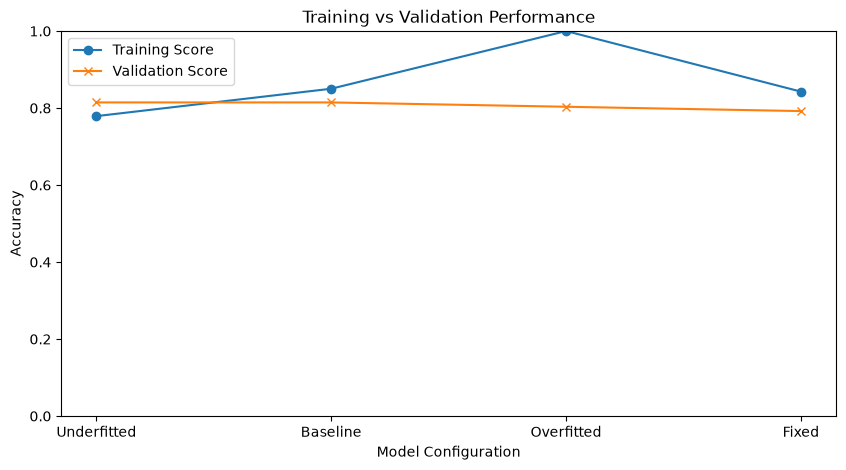

In [13]:
models = [
    "Underfitted",
    "Baseline",
    "Overfitted",
    "Fixed"
]

train_scores = [
    underfit_train_score,
    model_train_score,
    overfit_train_score,
    fix_train_score
]

val_scores = [
    underfit_val_score,
    model_val_score,
    overfit_val_score,
    fix_val_score
]

x = range(len(models))

plt.figure(figsize=(10, 5))

plt.plot(x,train_scores,marker="o",label="Training Score")

plt.plot(x, val_scores, marker="x", label="Validation Score")

plt.xticks(x, models)
plt.ylim(0, 1)

plt.xlabel("Model Configuration")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Performance")

plt.legend()

plt.show()

### Plot Interpretation

The plot summarizes the behavior of the four models.

The underfitted model has limited capacity, so both training and validation performance are relatively weak.

As model complexity increases, the training score improves.

However, the overfitted model creates a large separation between training and validation performance.

This separation represents high variance and poor generalization.

The fixed model controls complexity and aims to reduce this gap.

The desired model is not simply the one with the highest training score.

Instead, the target is a model with strong validation performance and a reasonably small train-validation gap.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 15. Understanding the Bias-Variance Trade-off

The experiments demonstrate the bias-variance trade-off using actual Titanic passenger data.

### Underfitting

The model is too simple.

- High bias
- Low model complexity
- Low training performance
- Low validation performance

### Overfitting

The model is too complex.

- High variance
- High model complexity
- Very high training performance
- Lower validation performance
- Large train-validation gap

### Better Fit

A better model balances the two.

It should be complex enough to learn meaningful relationships but constrained enough to generalize to unseen passengers.

Therefore:

> Increasing complexity can reduce bias, but excessive complexity can increase variance.

<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 16. Ridge and Lasso Regularization

Regularization is another important technique for controlling model complexity.

For linear regression models, two common regularization techniques are Ridge and Lasso.

### Ridge — L2 Regularization

Ridge adds a penalty based on the squared model coefficients.

It encourages coefficients to become smaller.


In [14]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

Lasso — L1 Regularization

Lasso adds a penalty based on the absolute values of the model coefficients.

It can shrink some coefficients exactly to zero, which can effectively perform feature selection.

In [15]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

The alpha parameter controls the strength of regularization.

A larger alpha means a stronger penalty and a simpler model.

In this hands-on experiment, I used Decision Tree complexity controls instead because Survived is a classification target.

The important common idea is that regularization or complexity constraints can reduce overfitting by preventing the model from becoming unnecessarily complex.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 17. Visualizing the Overfitting Gap

The numerical scores show the difference between training and validation performance.

I will visualize these scores to make the generalization gap easier to identify.

The question is:

> Is the model's performance substantially different on training and validation data?

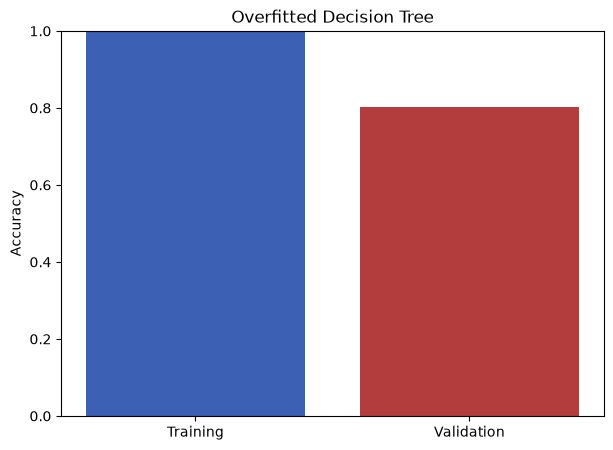

In [16]:
plt.figure(figsize=(7, 5))
plt.bar(["Training", "Validation"],[overfit_train_score, overfit_val_score],color=["#3c60b3", "#b33c3c"])

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Overfitted Decision Tree")

plt.show()

### Plot Interpretation

The training bar represents the model's performance on data it has already seen.

The validation bar represents performance on unseen data.

A large difference between the two bars indicates a large generalization gap.

Therefore, the plot supports the numerical evidence that the unrestricted Decision Tree is overfitting.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

## 18. Final Evaluation on the Test Set

The validation set was used to diagnose model fit and select the final model configuration.

The test set has not been used during these decisions.

Now that the model has been selected, I can perform one final evaluation on the unseen test data.

This provides an unbiased estimate of how the selected model performs on data it has never seen.

In [17]:
test_score = fix_model.score(x_test, y_test)

print("Final Test Accuracy:", test_score)

Final Test Accuracy: 0.8044692737430168


The final test score represents the performance of the selected model on completely unseen passenger data.

Because the test set was kept separate during model diagnosis and tuning, this score provides a more reliable estimate of the model's generalization performance.
<hr style="height: 5px; background-color: #b33c3c ; border: none;">

# 19. Final Conclusion

In this hands-on lab, I investigated the bias-variance trade-off using the Titanic dataset.

I deliberately created an overfitted model by allowing the Decision Tree to grow without a depth restriction.

The evidence was the difference between its training and validation scores.

I then created an underfitted model by restricting the tree to a very small depth.

This demonstrated the opposite behavior: the model was too simple to learn the underlying patterns effectively.

Finally, I controlled the complexity of the overfitted model using `max_depth` and `min_samples_leaf`.

The comparison of training score, validation score, and train-validation gap provided evidence for whether the model was underfitting, overfitting, or generalizing reasonably well.

The main lesson from this experiment is:

> A high training score alone does not mean that a model is good. The model must also generalize well to unseen data.

The train-validation gap is therefore an important diagnostic tool when deciding whether a model is too simple, too complex, or appropriately fitted.